#  Cargar todos los archivos CSV que se encuentran en la carpeta GuardarDatos. Luego los uniremos en una sola tabla.

In [2]:
# Importar librerías necesarias
import pandas as pd
import os

# Paso 1: Cargar los archivos CSV de la carpeta "GuardarDatos"
# Obtener la lista de todos los archivos CSV en la carpeta "GuardarDatos"
folder_path = '../db/'
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Leer todos los archivos CSV y concatenarlos en un solo DataFrame
df_list = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# Concatenar todos los DataFrames en uno solo
df_concatenado = pd.concat(df_list, ignore_index=True)

# Ver las primeras filas del DataFrame concatenado
df_concatenado.head()


,tweet_id,tweet_text,comentario,comentario_autor,fecha_publicacion,timestamp_extraccion,replies,reposts,likes,views,tweet_id_nuevo,clasificacion
0,id_¡El_#IMSS_también_es_deporte!_,"""¡El #IMSS también es deporte! Mantente activo...","""¿Podrías compartir las actividades que tiene ...","""Víctor Sócrates @victor_socrates · 1h""",2025-07-19T20:13:25.000Z,2025-07-19T16:42:37.431398,1.0,1,1,613,NaN,NaN
1,id_El_fentanilo_te_engancha_desde,"""El fentanilo te engancha desde la primera vez...","""**VERIFIQUÉ Y NO HAY NINGÚN COMENTARIO**""","""**VERIFIQUÉ Y NO HAY NINGÚN COMENTARIO**""",2025-07-19T19:00:01.000Z,2025-07-19T16:42:41.987489,0.0,0,0,736,NaN,NaN
2,"id_Asiste_Mtro._Zoé_Robledo,_dire","""Asiste Mtro. Zoé Robledo, director general de...","""Ese estado es un estado fallido el personal t...","""Michel Foucault @MichelFoucaul17 · 2h""",2025-07-19T18:47:30.000Z,2025-07-19T16:42:46.681982,1.0,1,1,1242,NaN,NaN
3,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Comentario no encontrado""","""_K40S_PUP @KAOS_Pup40 · 21h""",2025-07-19T02:20:58.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
4,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Comentario no encontrado""","""LastPatriot47 @LastPatriot17 · Jul 18""",2025-07-18T19:37:11.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN


In [12]:
df_concatenado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 227 entries, 0 to 238
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              227 non-null    object 
 1   tweet_text            227 non-null    object 
 2   comentario            227 non-null    object 
 3   comentario_autor      227 non-null    object 
 4   fecha_publicacion     227 non-null    object 
 5   timestamp_extraccion  227 non-null    object 
 6   replies               214 non-null    float64
 7   reposts               227 non-null    int64  
 8   likes                 227 non-null    int64  
 9   views                 227 non-null    int64  
 10  tweet_id_nuevo        24 non-null     float64
 11  clasificacion         12 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 23.1+ KB


## Nulos

<Axes: >

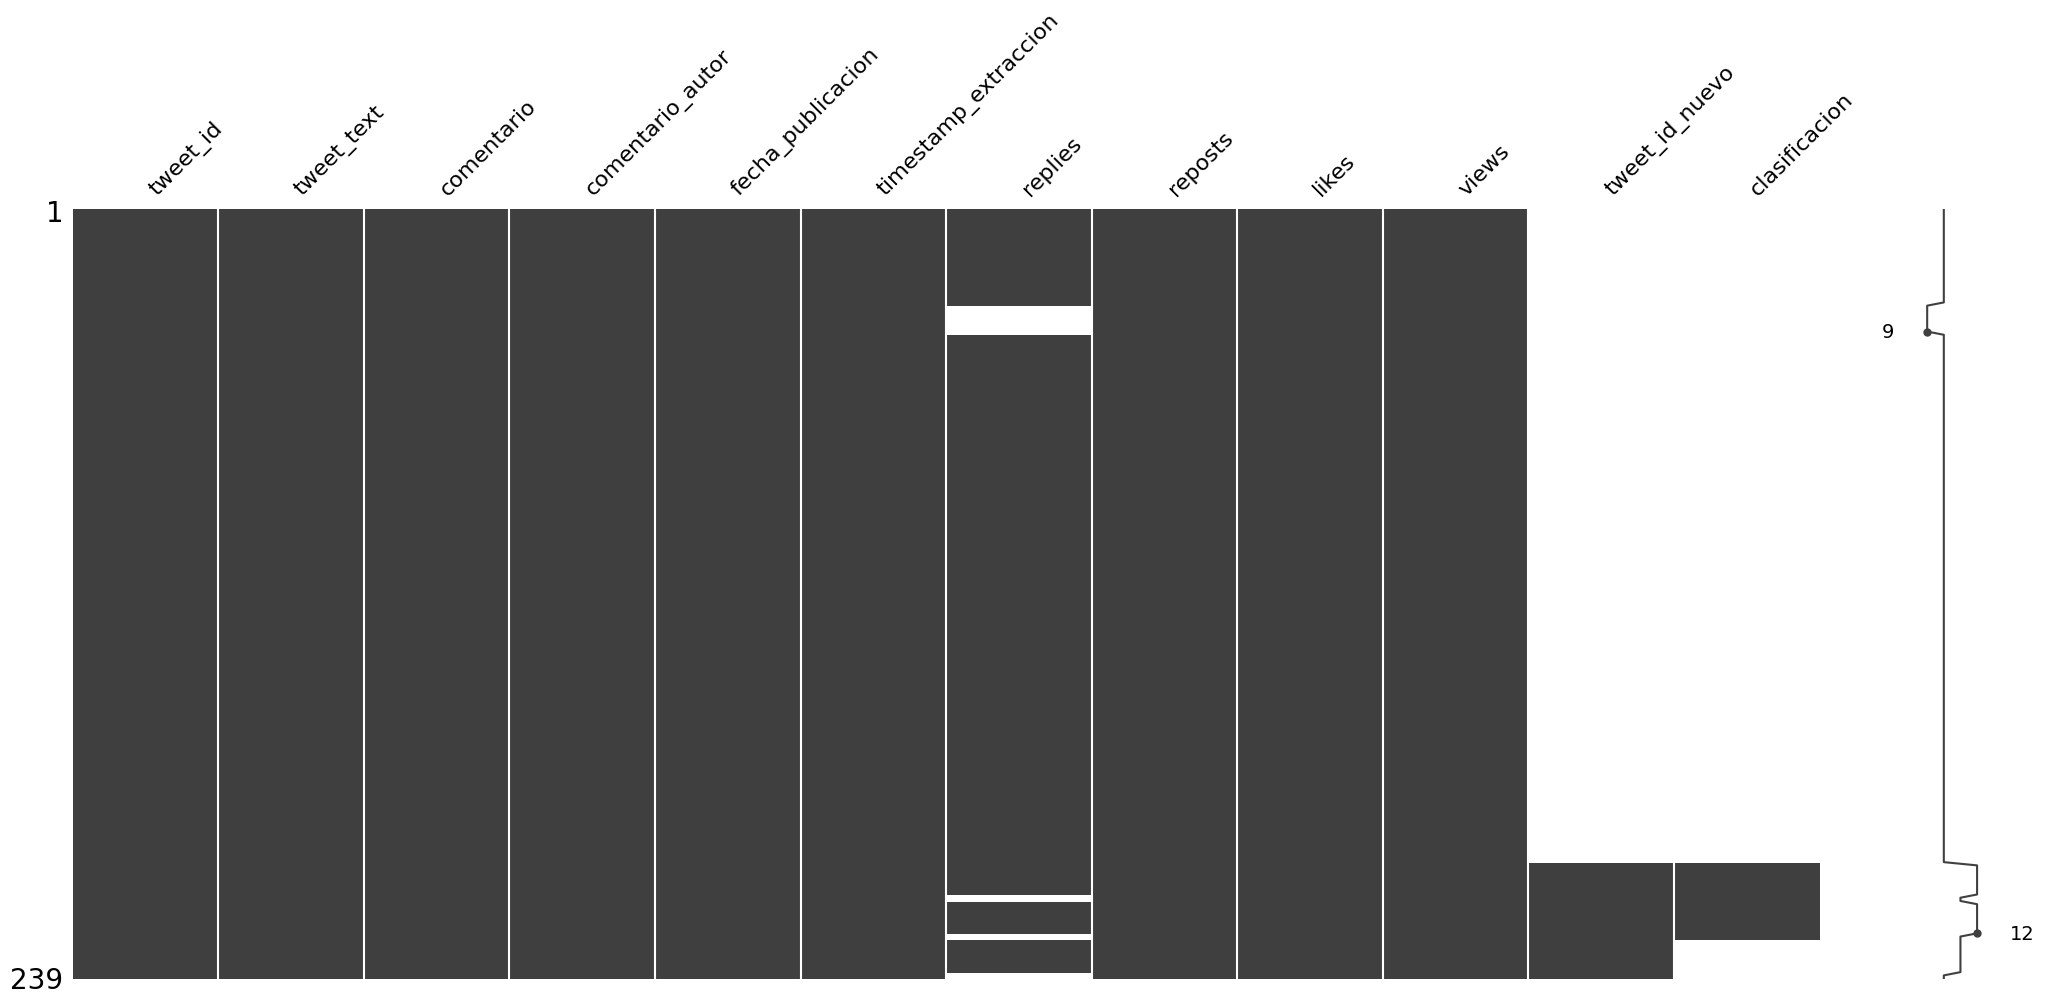

In [5]:
#%pip install missingno
import missingno as msno

msno.matrix(df_concatenado)

In [4]:
df_concatenado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              39 non-null     object 
 1   tweet_text            39 non-null     object 
 2   comentario            39 non-null     object 
 3   comentario_autor      39 non-null     object 
 4   fecha_publicacion     39 non-null     object 
 5   timestamp_extraccion  39 non-null     object 
 6   replies               30 non-null     float64
 7   reposts               39 non-null     int64  
 8   likes                 39 non-null     int64  
 9   views                 39 non-null     int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 3.2+ KB


In [6]:
df_nulos_df_concatenado = df_concatenado.isnull().sum()

df_nulos_df_concatenado

tweet_id                  0
tweet_text                0
comentario                0
comentario_autor          0
fecha_publicacion         0
timestamp_extraccion      0
replies                  15
reposts                   0
likes                     0
views                     0
tweet_id_nuevo          203
clasificacion           215
dtype: int64

# Verificar duplicados en los datos

In [7]:
# Paso 2: Verificar duplicados
# Comprobar duplicados basados en la columna 'tweet_id'
df_concatenado_duplicados = df_concatenado[df_concatenado.duplicated(subset='comentario', keep=False)]

# Mostrar los duplicados
df_concatenado_duplicados.head(20)


,tweet_id,tweet_text,comentario,comentario_autor,fecha_publicacion,timestamp_extraccion,replies,reposts,likes,views,tweet_id_nuevo,clasificacion
0,id_¡El_#IMSS_también_es_deporte!_,"""¡El #IMSS también es deporte! Mantente activo...","""¿Podrías compartir las actividades que tiene ...","""Víctor Sócrates @victor_socrates · 1h""",2025-07-19T20:13:25.000Z,2025-07-19T16:42:37.431398,1.0,1,1,613,NaN,NaN
1,id_El_fentanilo_te_engancha_desde,"""El fentanilo te engancha desde la primera vez...","""**VERIFIQUÉ Y NO HAY NINGÚN COMENTARIO**""","""**VERIFIQUÉ Y NO HAY NINGÚN COMENTARIO**""",2025-07-19T19:00:01.000Z,2025-07-19T16:42:41.987489,0.0,0,0,736,NaN,NaN
2,"id_Asiste_Mtro._Zoé_Robledo,_dire","""Asiste Mtro. Zoé Robledo, director general de...","""Ese estado es un estado fallido el personal t...","""Michel Foucault @MichelFoucaul17 · 2h""",2025-07-19T18:47:30.000Z,2025-07-19T16:42:46.681982,1.0,1,1,1242,NaN,NaN
3,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Comentario no encontrado""","""_K40S_PUP @KAOS_Pup40 · 21h""",2025-07-19T02:20:58.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
4,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Comentario no encontrado""","""LastPatriot47 @LastPatriot17 · Jul 18""",2025-07-18T19:37:11.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
5,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Nunca estuvimos PEOR! Ahora ya se quedarán en...","""Ana Schwarz @anaschwarz · Jul 18""",2025-07-18T14:21:53.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
6,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Vamos México @Claudiashein""","""Maria Ostos @LaschwarzMaria · Jul 18""",2025-07-18T13:55:56.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
7,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""La fiscalía investiga lo que manda el gobiern...","""cony @ev_coky · Jul 18""",2025-07-18T14:41:12.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
8,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""Porque un canal de difusión de áreas protegid...","""Del Piero @PieroD803109941 · Jul 18""",2025-07-18T13:43:22.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN
9,id_#MañaneraDelPueblo_desde_Palac,"""#MañaneraDelPueblo desde Palacio Nacional. Vi...","""#LaMañaneraQueNadieVe""","""Jobless guy @Joblessguyy_ · Jul 18""",2025-07-18T13:46:59.000Z,2025-07-19T19:02:52.182533,47.0,276,327,0,NaN,NaN


In [8]:
df_concatenado_duplicados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 0 to 238
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              163 non-null    object 
 1   tweet_text            163 non-null    object 
 2   comentario            163 non-null    object 
 3   comentario_autor      163 non-null    object 
 4   fecha_publicacion     163 non-null    object 
 5   timestamp_extraccion  163 non-null    object 
 6   replies               153 non-null    float64
 7   reposts               163 non-null    int64  
 8   likes                 163 non-null    int64  
 9   views                 163 non-null    int64  
 10  tweet_id_nuevo        36 non-null     float64
 11  clasificacion         24 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 16.6+ KB


# Verificar duplicados

In [9]:
duplicados_todas_columnas_2 = df_concatenado[df_concatenado.duplicated(keep=False)]
print(f"Número de registros duplicados en todas las columnas: {duplicados_todas_columnas_2.shape[0]}")

Número de registros duplicados en todas las columnas: 24


## Eliminar duplicados

In [11]:

#df_concatenado_limpio = df_concatenado.drop_duplicates(subset='tweet_id', keep='first')
df_concatenado_limpio = df_concatenado.drop_duplicates(keep='first')  # o keep=False si quieres eliminarlos todos

# Verificar que los duplicados han sido eliminados

df_concatenado_limpio.count()


tweet_id                227
tweet_text              227
comentario              227
comentario_autor        227
fecha_publicacion       227
timestamp_extraccion    227
replies                 214
reposts                 227
likes                   227
views                   227
tweet_id_nuevo           24
clasificacion            12
dtype: int64

# Paso 4: Reemplazar el tweet_id con un número único

In [13]:
# Paso 4: Reemplazar tweet_id con un número único
df_concatenado_limpio['tweet_id_nuevo'] = range(1, len(df_concatenado_limpio) + 1)

# Verificar el cambio
df_concatenado_limpio.count()

tweet_id                227
tweet_text              227
comentario              227
comentario_autor        227
fecha_publicacion       227
timestamp_extraccion    227
replies                 214
reposts                 227
likes                   227
views                   227
tweet_id_nuevo          227
clasificacion            12
dtype: int64

# Paso 5: Guardar los datos limpios en un nuevo archivo CSV

In [15]:
# Paso 5: Guardar el DataFrame limpio en un nuevo archivo CSV
output_file = '../db/tweets_limpios.csv'
df_concatenado_limpio.to_csv(output_file, index=False)

# Confirmar que el archivo se ha guardado correctamente
print(f"Los datos limpios han sido guardados en: {output_file}")


Los datos limpios han sido guardados en: ../db/tweets_limpios.csv


# Código completo pero mejor el anterior


In [ ]:
# Importar las librerías necesarias
import pandas as pd
import os

# Paso 1: Cargar los archivos CSV de la carpeta "GuardarDatos"
folder_path = 'GuardarDatos/'
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Leer todos los archivos CSV y concatenarlos en un solo DataFrame
df_list = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# Concatenar todos los DataFrames en uno solo
df_concatenado = pd.concat(df_list, ignore_index=True)

# Ver las primeras filas del DataFrame concatenado
df_concatenado.head()

# Paso 2: Verificar duplicados
df_concatenado_duplicados = df_concatenado[df_concatenado.duplicated(subset='tweet_id', keep=False)]

# Mostrar los duplicados
df_concatenado_duplicados.head()

# Paso 3: Eliminar los duplicados
df_concatenado_limpio = df_concatenado.drop_duplicates(subset='tweet_id', keep='first')

# Verificar que los duplicados han sido eliminados
df_concatenado_limpio.head()

# Paso 4: Reemplazar tweet_id con un número único
df_concatenado_limpio['tweet_id_nuevo'] = range(1, len(df_concatenado_limpio) + 1)

# Verificar el cambio
df_concatenado_limpio.head()

# Paso 5: Guardar el DataFrame limpio en un nuevo archivo CSV
output_file = 'db/tweets_limpios.csv'
df_concatenado_limpio.to_csv(output_file, index=False)

# Confirmar que el archivo se ha guardado correctamente
print(f"Los datos limpios han sido guardados en: {output_file}")


# Resumen

Este notebook realiza las siguientes tareas:

Carga los archivos CSV de la carpeta GuardarDatos.

Une todos los archivos en un solo DataFrame.

Verifica y muestra los duplicados basados en el tweet_id.

Elimina los duplicados.

Reemplaza el tweet_id por un índice numérico único.

Guarda los datos procesados en un nuevo archivo CSV.